In [2]:

# Adding noise to the basic broadcasting protocol from Hillery et al

import numpy as np
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.io as pio
import itertools
from math import comb
warnings.filterwarnings('ignore')
np.set_printoptions(linewidth=500)
np.set_printoptions(precision=3, suppress=True)
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.visualization import plot_bloch_vector, plot_bloch_multivector
from qiskit.quantum_info import DensityMatrix, Operator, Statevector, Pauli, partial_trace, state_fidelity

# Applying dephasing noise to Bob and Charlie's qubits
def dephasing_channel(rho, p):
    """Apply a dephasing channel with probability p to Bob and Charlies qubits in density matrix rho."""
    rho_mat = rho.data
    
    evolv_1 = np.kron(np.eye(3), Pauli('ZI').to_matrix())
    evolv_2 = np.kron(np.eye(3), Pauli('IZ').to_matrix())
    evolv_3 = np.kron(np.eye(3), Pauli('ZZ').to_matrix())

    rho_1 = evolv_1 @ rho_mat @ evolv_1.conj().T
    rho_2 = evolv_2 @ rho_mat @ evolv_2.conj().T
    rho_3 = evolv_3 @ rho_mat @ evolv_3.conj().T

    return (1-p)**2 * rho + p*(1-p) * (rho_1 + rho_2) + p**2 * rho_3

# Applying bitflip noise to Bob and Charlie's qubits
def bitflip_channel(rho, p):
    """Apply a bitflip channel with probability p to Bob and Charlies qubits in density matrix rho."""
    rho_mat = rho.data
    
    evolv_1 = np.kron(np.eye(3), Pauli('XI').to_matrix())
    evolv_2 = np.kron(np.eye(3), Pauli('IX').to_matrix())
    evolv_3 = np.kron(np.eye(3), Pauli('XX').to_matrix())

    rho_1 = evolv_1 @ rho_mat @ evolv_1.conj().T
    rho_2 = evolv_2 @ rho_mat @ evolv_2.conj().T
    rho_3 = evolv_3 @ rho_mat @ evolv_3.conj().T

    return (1-p)**2 * rho + p*(1-p) * (rho_1 + rho_2) + p**2 * rho_3

# Applying depolarizing noise to Bob and Charlie's qubits
def depolarizing_channel(rho, p):
    """Apply a depolarizing channel with probability p to Bob and Charlies qubits in density matrix rho."""
    rho_mat = rho.data
    # First applying to Bob's qubit
    evolve_x = np.kron(np.eye(3), Pauli('XI').to_matrix())
    evolve_y = np.kron(np.eye(3), Pauli('YI').to_matrix())
    evolve_z = np.kron(np.eye(3), Pauli('ZI').to_matrix())
    
    rho_mat = (1 - p) * rho_mat + (p / 3) * (evolve_x @ rho_mat @ evolve_x.conj().T +
                                             evolve_y @ rho_mat @ evolve_y.conj().T +
                                             evolve_z @ rho_mat @ evolve_z.conj().T)
    # Then applying to Charlie's qubit
    evolve_x = np.kron(np.eye(3), Pauli('IX').to_matrix())
    evolve_y = np.kron(np.eye(3), Pauli('IY').to_matrix())
    evolve_z = np.kron(np.eye(3), Pauli('IZ').to_matrix())
    
    rho_mat = (1 - p) * rho_mat + (p / 3) * (evolve_x @ rho_mat @ evolve_x.conj().T +
                                             evolve_y @ rho_mat @ evolve_y.conj().T +
                                             evolve_z @ rho_mat @ evolve_z.conj().T)
    return rho_mat

# Alice now applies her unitary operation to her qutrit
def alice_unitary(rho, theta):
    rho_mat = rho.data
    # 3×3 qutrit unitary (your original definition)
    Uq = np.eye(3, dtype=complex)
    Uq[0, 0] = np.exp(2j * theta)
    Uq[1, 1] = np.exp(-2j * theta)
    U_full = np.kron(Uq, np.eye(4, dtype=complex))  # Extend to full space
    # Apply on the whole system
    rhoU = DensityMatrix(U_full @ rho_mat @ U_full.conj().T)

    return rhoU

# Alice now measures in a special basis
def measure_alice(rho, outcome=None):
    rho_mat = rho.data
    basis_0 = (1/np.sqrt(3)) * np.array([1, 1, 1])
    basis_1 = (1/np.sqrt(3)) * np.array([np.exp(2j*np.pi/3), np.exp(-2j*np.pi/3), 1])
    basis_2 = (1/np.sqrt(3)) * np.array([np.exp(-2j*np.pi/3), np.exp(2j*np.pi/3), 1])

    proj_0 = np.outer(basis_0, basis_0.conj())
    proj_1 = np.outer(basis_1, basis_1.conj())
    proj_2 = np.outer(basis_2, basis_2.conj())
    # Projectors on full space (qutrit + 2 qubits)
    proj_0 = np.kron(proj_0, np.eye(4))
    proj_1 = np.kron(proj_1, np.eye(4))
    proj_2 = np.kron(proj_2, np.eye(4))

    projectors = [proj_0, proj_1, proj_2]

    # Returning a random outcome
    probs = np.array([np.trace(P @ rho_mat).real for P in projectors], dtype=float)
    probs = np.clip(probs, 0.0, None)
    probs = probs / np.sum(probs)  # guard tiny negative numerical noise
    if outcome is None:
        outcome = np.random.choice([0, 1, 2], p=probs)
    

    rho_0 = proj_0 @ rho_mat @ proj_0.conj().T
    rho_1 = proj_1 @ rho_mat @ proj_1.conj().T
    rho_2 = proj_2 @ rho_mat @ proj_2.conj().T

    final_state = [rho_0, rho_1, rho_2][outcome] / probs[outcome]
    final_state = DensityMatrix(final_state)
    return final_state, outcome

# Bob and Charlie apply corrections based on Alice's outcome
def apply_corrections(rho, outcome):
    if outcome == 0:
        return rho  # No correction
    
    plus, minus = np.exp(1j * np.pi / 3), np.exp(-1j * np.pi / 3)
    Ub = np.array([[plus, 0], [0, minus]], dtype=complex)
    if outcome == 2:
        Ub = Ub.conj().T  # inverse (swap phases)

    U_full = np.kron(np.eye(3), np.kron(Ub, Ub))  # I_3 ⊗ Ub ⊗ Ub  (12×12)
    data = U_full @ rho.data @ U_full.conj().T
    return DensityMatrix(data)

# Partial trace implementation for numpy arrays
def partial_trace_np(rho, dims, keep):
    """
    Partial trace for a density matrix `rho` (numpy 2D array) over a product space
    with local dimensions `dims` (e.g., (3,2,2) for qutrit⊗qubit⊗qubit).
    `keep` is a list of subsystem indices to keep (e.g., [1] to keep Bob).

    Returns a numpy 2D array for the reduced density matrix on the kept subsystems.
    """
    dims = list(dims)
    N = len(dims)
    keep = sorted(keep)
    trace_out = [i for i in range(N) if i not in keep]

    # reshape ρ → rank-2N tensor with one index per subsystem on bra and ket
    rho = rho.data
    rho_t = rho.reshape(dims + dims)  # indices: (a,b,c, a',b',c') for dims=(3,2,2)

    # trace out each unwanted subsystem: contract axis s with its paired axis s+N
    for s in sorted(trace_out, reverse=True):
        rho_t = np.trace(rho_t, axis1=s, axis2=s+len(dims))
        dims.pop(s)

    # collapse back to a matrix on the kept subsystems
    d_kept = int(np.prod(dims)) if dims else 1
    return rho_t.reshape(d_kept, d_kept)

def basic_broadcasting_with_dephasing(alpha_val=1/np.sqrt(2), theta_val=np.pi/8, p=0.1, outcome=None):
    beta_val = np.sqrt(1 - alpha_val**2)
    target_state = Statevector( [alpha_val * np.exp(1j*theta_val), beta_val * np.exp(-1j*theta_val)] )
    initial_state = Statevector( [alpha_val**2, 0, 0, 0, 0, 0, 0, beta_val**2, 0, alpha_val*beta_val, alpha_val*beta_val, 0])
    initial_rho = DensityMatrix(initial_state) # Alice has qutrit, Bob and Charlie have qubits

    noisy_rho = dephasing_channel(initial_rho, p=p)
    final_rho = alice_unitary(noisy_rho, theta_val)
    rho_post_measurement, outcome = measure_alice(final_rho, outcome=outcome)
    corrected_rho = apply_corrections(rho_post_measurement, outcome)

    # Getting Bob and Charlie's reduced density matrices
    bob_rho = DensityMatrix(partial_trace_np(corrected_rho, dims=(3,2,2), keep=[1]))  # 2×2
    charlie_rho = DensityMatrix(partial_trace_np(corrected_rho, dims=(3,2,2), keep=[2]))  # 2×2

    # Get the fidelities
    return state_fidelity(bob_rho, DensityMatrix(target_state)), state_fidelity(charlie_rho, DensityMatrix(target_state))

def basic_broadcasting_with_bitflip(alpha_val=1/np.sqrt(2), theta_val=np.pi/8, p=0.1, outcome=None):
    beta_val = np.sqrt(1 - alpha_val**2)
    target_state = Statevector( [alpha_val * np.exp(1j*theta_val), beta_val * np.exp(-1j*theta_val)] )
    initial_state = Statevector( [alpha_val**2, 0, 0, 0, 0, 0, 0, beta_val**2, 0, alpha_val*beta_val, alpha_val*beta_val, 0])
    initial_rho = DensityMatrix(initial_state) # Alice has qutrit, Bob and Charlie have qubits

    noisy_rho = bitflip_channel(initial_rho, p=p)
    final_rho = alice_unitary(noisy_rho, theta_val)
    rho_post_measurement, outcome = measure_alice(final_rho, outcome=outcome)
    corrected_rho = apply_corrections(rho_post_measurement, outcome)

    # Getting Bob and Charlie's reduced density matrices
    bob_rho = DensityMatrix(partial_trace_np(corrected_rho, dims=(3,2,2), keep=[1]))  # 2×2
    charlie_rho = DensityMatrix(partial_trace_np(corrected_rho, dims=(3,2,2), keep=[2]))  # 2×2
    # Get the fidelities
    return state_fidelity(bob_rho, DensityMatrix(target_state)), state_fidelity(charlie_rho, DensityMatrix(target_state))

def basic_broadcasting_with_depolarizing(alpha_val=1/np.sqrt(2), theta_val=np.pi/8, p=0.1, outcome=None):
    beta_val = np.sqrt(1 - alpha_val**2)
    target_state = Statevector( [alpha_val * np.exp(1j*theta_val), beta_val * np.exp(-1j*theta_val)] )
    initial_state = Statevector( [alpha_val**2, 0, 0, 0, 0, 0, 0, beta_val**2, 0, alpha_val*beta_val, alpha_val*beta_val, 0])
    initial_rho = DensityMatrix(initial_state) # Alice has qutrit, Bob and Charlie have qubits

    noisy_rho = depolarizing_channel(initial_rho, p=p)
    final_rho = alice_unitary(noisy_rho, theta_val)
    rho_post_measurement, outcome = measure_alice(final_rho, outcome=outcome)
    corrected_rho = apply_corrections(rho_post_measurement, outcome)

    # Getting Bob and Charlie's reduced density matrices
    bob_rho = DensityMatrix(partial_trace_np(corrected_rho, dims=(3,2,2), keep=[1]))  # 2×2
    charlie_rho = DensityMatrix(partial_trace_np(corrected_rho, dims=(3,2,2), keep=[2]))  # 2×2

    # Get the fidelities
    return state_fidelity(bob_rho, DensityMatrix(target_state)), state_fidelity(charlie_rho, DensityMatrix(target_state))



In [ ]:
# First plotting fidelities with fixed alpha and theta values
alpha_vals = [-1, -1/np.sqrt(2), -1/2, 0, 1/2, 1/np.sqrt(2), 1]
theta_vals = [0, np.pi/8, np.pi/2]

p_vals = np.linspace(0, 1, 100)

for alpha_val in alpha_vals:
    for theta_val in theta_vals:
        

        dephase_fidelities, depolarize_fidelities, bitflip_fidelities = [], [], []

        for p in p_vals:
            fidelity_phase, fidelity_pol, fidelity_flip = 0, 0, 0
            for outcome in [0, 1, 2]:
                dephase_bob, dephase_charlie = basic_broadcasting_with_dephasing(alpha_val=alpha_val, theta_val=theta_val, p=p, outcome=outcome)
                depolarize_bob, depolarize_charlie = basic_broadcasting_with_depolarizing(alpha_val=alpha_val, theta_val=theta_val, p=p, outcome=outcome)
                bitflip_bob, bitflip_charlie = basic_broadcasting_with_bitflip(alpha_val=alpha_val, theta_val=theta_val, p=p, outcome=outcome)
                fidelity_phase += dephase_bob
                fidelity_pol += depolarize_bob
                fidelity_flip += bitflip_bob
                
            dephase_fidelities.append(fidelity_phase/3)
            depolarize_fidelities.append(fidelity_pol/3)
            bitflip_fidelities.append(fidelity_flip/3)
                

        plt.figure(figsize=(10, 6))
        plt.plot(p_vals, dephase_fidelities, label='Dephasing Channel', color='blue')
        plt.plot(p_vals, depolarize_fidelities, label='Depolarizing Channel', color='green')
        plt.plot(p_vals, bitflip_fidelities, label='Bitflip Channel', color='red')
        plt.xlabel('Noise Probability (p)')
        plt.ylabel('Fidelity')
        plt.title(f'Fidelity vs Noise Probability for Different Channels, α={alpha_val:.2f}, θ={theta_val:.2f}')
        plt.legend()
        plt.grid(True)
        # plt.show()
        # saving plot to file
        plt.savefig(f'fidelity_vs_noise_alpha_{alpha_val:.2f}_theta_{theta_val:.2f}.png')

In [ ]:
# Plotting Target states on the Bloch Sphere

for alpha_val in alpha_vals:
    for theta_val in theta_vals:
        beta_val = np.sqrt(1 - alpha_val**2)
        target_state = Statevector( [alpha_val * np.exp(1j*theta_val), beta_val * np.exp(-1j*theta_val)] )
        target_state.draw('bloch')
        # Saving plot to file
        plt.savefig(f'target_state_bloch_sphere_alpha_{alpha_val:.2f}_theta_{theta_val:.2f}.png')

In [2]:
# Plotting fidelities
dephasing_probs = np.linspace(0, 1, 100)
alpha_vals = np.linspace(-1, 1, 200)

fidelities_bob1, fidelities_charlie1 = [], []

for p in dephasing_probs:
    for alpha in alpha_vals:
        fidelity_bob, fidelity_charlie = 0, 0
        for outcome in [0, 1, 2]:
            fidelity_bob_outcome, fidelity_charlie_outcome = basic_broadcasting_with_dephasing(alpha_val=alpha, theta_val=np.pi/8, p=p, outcome=outcome)
            fidelity_bob += fidelity_bob_outcome
            fidelity_charlie += fidelity_charlie_outcome
        
        fidelities_bob1.append(fidelity_bob/3)
        fidelities_charlie1.append(fidelity_charlie/3)



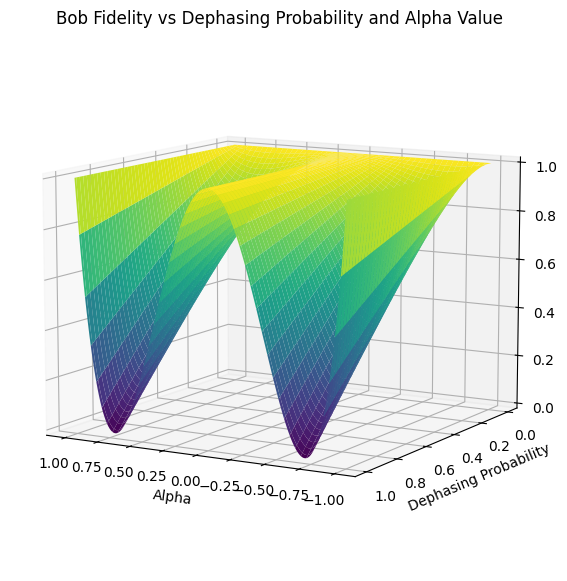

In [21]:
# Surface plot of Bob fidelities
# %matplotlib widget

F_bob = np.array(fidelities_bob1).reshape(len(dephasing_probs), len(alpha_vals))
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(alpha_vals, dephasing_probs)
ax.plot_surface(X, Y, F_bob, cmap='viridis')
ax.set_xlabel('Alpha')
ax.set_ylabel('Dephasing Probability')
ax.set_zlabel('Fidelity')
plt.title('Bob Fidelity vs Dephasing Probability and Alpha Value')
# Rotate for better view
ax.view_init(elev=10, azim=120)
plt.show()

# plt.savefig(f'Dephasing_Surface_2.png')


In [3]:
# Plotting fidelities
bitflip_probs = np.linspace(0, 1, 100)

fidelities_bob2, fidelities_charlie2 = [], []

for p in bitflip_probs:
    for alpha in alpha_vals:
        fidelity_bob, fidelity_charlie = 0, 0
        for outcome in [0, 1, 2]:
            fidelity_bob_outcome, fidelity_charlie_outcome = basic_broadcasting_with_bitflip(alpha_val=alpha, theta_val=np.pi/8, p=p, outcome=outcome)
            fidelity_bob += fidelity_bob_outcome
            fidelity_charlie += fidelity_charlie_outcome
        
        fidelities_bob2.append(fidelity_bob/3)
        fidelities_charlie2.append(fidelity_charlie/3)




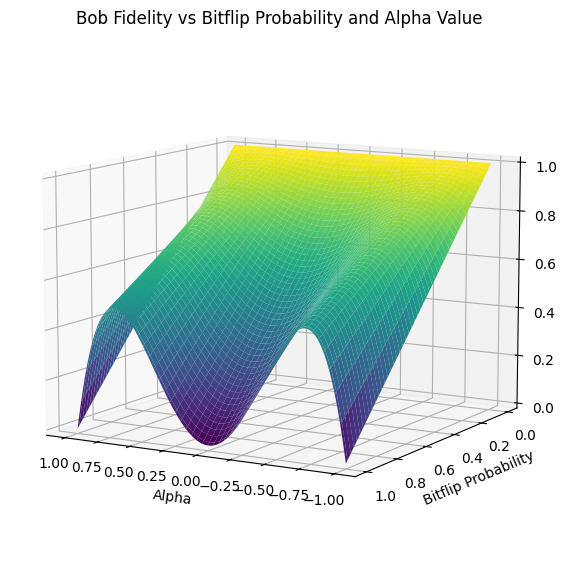

In [24]:
# Surface plot of Bob fidelities
# %matplotlib widget
F_bob = np.array(fidelities_bob2).reshape(len(bitflip_probs), len(alpha_vals))
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(alpha_vals, bitflip_probs)
ax.plot_surface(X, Y, F_bob, cmap='viridis')
ax.set_xlabel('Alpha')
ax.set_ylabel('Bitflip Probability')
ax.set_zlabel('Fidelity')
plt.title('Bob Fidelity vs Bitflip Probability and Alpha Value')
# Rotate for better view
ax.view_init(elev=10, azim=120)
plt.show()

# plt.savefig(f'Bitflip_Surface_2.png')

In [4]:
# Plotting fidelities
depolarize_probs = np.linspace(0, 1, 100)

fidelities_bob3, fidelities_charlie3 = [], []

for p in depolarize_probs:
    for alpha in alpha_vals:
        fidelity_bob, fidelity_charlie = 0, 0
        for outcome in [0, 1, 2]:
            fidelity_bob_outcome, fidelity_charlie_outcome = basic_broadcasting_with_depolarizing(alpha_val=alpha, theta_val=np.pi/8, p=p, outcome=outcome)
            fidelity_bob += fidelity_bob_outcome
            fidelity_charlie += fidelity_charlie_outcome
        
        fidelities_bob3.append(fidelity_bob/3)
        fidelities_charlie3.append(fidelity_charlie/3)



In [ ]:
# Surface plot of Bob fidelities
# %matplotlib widget
F_bob = np.array(fidelities_bob3).reshape(len(depolarize_probs), len(alpha_vals))
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(alpha_vals, depolarize_probs)
ax.plot_surface(X, Y, F_bob, cmap='viridis')
ax.set_xlabel('Alpha')
ax.set_ylabel('Depolarizing Probability')
ax.set_zlabel('Fidelity')
ax.set_zlim(0,1)
plt.title('Bob Fidelity vs Depolarizing Probability and Alpha Value')
# Rotate for better view
ax.view_init(elev=10, azim=120)
plt.show()

# plt.savefig(f'Depolarize_Surface_2.png')


In [64]:
# Creating the 2 senders broadcasting protocol

def alice1_unitary(rho, theta1):
    rho_mat = rho.data
    # 3×3 qutrit unitary (your original definition)
    Uq = np.eye(3, dtype=complex)
    Uq[0, 0] = np.exp(1j * theta1)
    Uq[2, 2] = np.exp(-1j * theta1)
    U_full = np.kron(Uq, np.eye(12, dtype=complex))  # Extend to full space
    # Apply on the whole system
    rhoU = DensityMatrix(U_full @ rho_mat @ U_full.conj().T)
    return rhoU

def alice2_unitary(rho, theta2):
    rho_mat = rho.data
    # 3×3 qutrit unitary (your original definition)
    Uq = np.eye(3, dtype=complex)
    Uq[0, 0] = np.exp(1j * theta2)
    Uq[2, 2] = np.exp(-1j * theta2)
    U_full = np.kron(np.eye(3, dtype=complex), Uq)  # Extend to full space
    U_full = np.kron(U_full, np.eye(4, dtype=complex))  # Extend to full space
    # Apply on the whole system
    rhoU = DensityMatrix(U_full @ rho_mat @ U_full.conj().T)
    return rhoU

def measure_alice1(rho, outcome=None):
    rho_mat = rho.data
    basis_0 = (1/np.sqrt(3)) * np.array([1, 1, 1])
    basis_1 = (1/np.sqrt(3)) * np.array([1, np.exp(2j*np.pi/3), np.exp(4j*np.pi/3)])
    basis_2 = (1/np.sqrt(3)) * np.array([1, np.exp(4j*np.pi/3), np.exp(8j*np.pi/3)])

    proj_0 = np.outer(basis_0, basis_0.conj())
    proj_1 = np.outer(basis_1, basis_1.conj())
    proj_2 = np.outer(basis_2, basis_2.conj())
    # Projectors on full space (qutrit + 2 qubits)
    proj_0 = np.kron(proj_0, np.eye(12))
    proj_1 = np.kron(proj_1, np.eye(12))
    proj_2 = np.kron(proj_2, np.eye(12))

    projectors = [proj_0, proj_1, proj_2]

    # Returning a random outcome
    probs = np.array([np.trace(P @ rho_mat).real for P in projectors], dtype=float)
    probs = np.clip(probs, 0.0, None)
    probs = probs / np.sum(probs)  # guard tiny negative numerical noise
    if outcome is None:
        outcome = np.random.choice([0, 1, 2], p=probs)
    

    rho_0 = proj_0 @ rho_mat @ proj_0.conj().T
    rho_1 = proj_1 @ rho_mat @ proj_1.conj().T
    rho_2 = proj_2 @ rho_mat @ proj_2.conj().T

    final_state = [rho_0, rho_1, rho_2][outcome] / probs[outcome]
    final_state = DensityMatrix(final_state)
    return final_state, outcome

def measure_alice2(rho, outcome=None):
    rho_mat = rho.data
    basis_0 = (1/np.sqrt(3)) * np.array([1, 1, 1])
    basis_1 = (1/np.sqrt(3)) * np.array([1, np.exp(2j*np.pi/3), np.exp(4j*np.pi/3)])
    basis_2 = (1/np.sqrt(3)) * np.array([1, np.exp(4j*np.pi/3), np.exp(8j*np.pi/3)])

    proj_0 = np.outer(basis_0, basis_0.conj())
    proj_1 = np.outer(basis_1, basis_1.conj())
    proj_2 = np.outer(basis_2, basis_2.conj())
    # Projectors on full space (qutrit + 2 qubits)
    proj_0 = np.kron(np.kron(np.eye(3), proj_0), np.eye(4))
    proj_1 = np.kron(np.kron(np.eye(3), proj_1), np.eye(4))
    proj_2 = np.kron(np.kron(np.eye(3), proj_2), np.eye(4))

    projectors = [proj_0, proj_1, proj_2]

    # Returning a random outcome
    probs = np.array([np.trace(P @ rho_mat).real for P in projectors], dtype=float)
    probs = np.clip(probs, 0.0, None)
    probs = probs / np.sum(probs)  # guard tiny negative numerical noise
    if outcome is None:
        outcome = np.random.choice([0, 1, 2], p=probs)
    

    rho_0 = proj_0 @ rho_mat @ proj_0.conj().T
    rho_1 = proj_1 @ rho_mat @ proj_1.conj().T
    rho_2 = proj_2 @ rho_mat @ proj_2.conj().T

    final_state = [rho_0, rho_1, rho_2][outcome] / probs[outcome]
    final_state = DensityMatrix(final_state)
    return final_state, outcome

def apply_corrections(rho, outcome1, outcome2):
    outcome = outcome1 + outcome2
    Ub = np.array([[1, 0], [0, np.exp(2j * np.pi * outcome / 3 )]], dtype=complex)

    U_full = np.kron(np.eye(9), np.kron(Ub, Ub))  # I_3 ⊗ Ub ⊗ Ub  (12×12)
    data = U_full @ rho.data @ U_full.conj().T
    return DensityMatrix(data)

def depolarizing_channel(rho, p1, p2):
    """Apply a depolarizing channel with probability p to Bob and Charlies qubits in density matrix rho."""
    rho_mat = rho.data
    # First applying to Bob's qubit
    evolve_x = np.kron(np.eye(9), Pauli('XI').to_matrix())
    evolve_y = np.kron(np.eye(9), Pauli('YI').to_matrix())
    evolve_z = np.kron(np.eye(9), Pauli('ZI').to_matrix())
    
    rho_mat = (1 - p1) * rho_mat + (p1 / 3) * (evolve_x @ rho_mat @ evolve_x.conj().T +
                                             evolve_y @ rho_mat @ evolve_y.conj().T +
                                             evolve_z @ rho_mat @ evolve_z.conj().T)
    # Then applying to Charlie's qubit
    evolve_x = np.kron(np.eye(9), Pauli('IX').to_matrix())
    evolve_y = np.kron(np.eye(9), Pauli('IY').to_matrix())
    evolve_z = np.kron(np.eye(9), Pauli('IZ').to_matrix())
    
    rho_mat = (1 - p2) * rho_mat + (p2 / 3) * (evolve_x @ rho_mat @ evolve_x.conj().T +
                                             evolve_y @ rho_mat @ evolve_y.conj().T +
                                             evolve_z @ rho_mat @ evolve_z.conj().T)
    return rho_mat


def two_alice_broadcasting_with_depolarizing(alpha_val=1/np.sqrt(2), theta1_val=np.pi/8, theta2_val=np.pi/6, p1=0.1, p2=0.1, outcome=None):
    beta_val = np.sqrt(1 - alpha_val**2)
    target_state = Statevector( [alpha_val * np.exp(1j*(theta1_val + theta2_val)/2), beta_val * np.exp(-1j*(theta1_val + theta2_val)/2)] )
    initial_state = Statevector([alpha_val**2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                            0, 0, 0, 0, 0, alpha_val*beta_val, alpha_val*beta_val, 0, 0, 0, 0, 0,
                            0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, beta_val**2])
    initial_rho = DensityMatrix(initial_state) # Alice has qutrit, Bob and Charlie have qubits


    noisy_rho = depolarizing_channel(initial_rho, p1=p1, p2=p2)
    final_rho = alice1_unitary(noisy_rho, theta1_val)
    final_rho = alice2_unitary(final_rho, theta2_val)
    
    
    rho_post_measurement, outcome1 = measure_alice1(final_rho, outcome=None)
    rho_post_measurement, outcome2 = measure_alice2(rho_post_measurement, outcome=None)
    
    corrected_rho = apply_corrections(rho_post_measurement, outcome1, outcome2)

    # Getting Bob and Charlie's reduced density matrices
    
    # Getting Bob and Charlie's reduced density matrices
    bob_rho = DensityMatrix(partial_trace_np(corrected_rho, dims=(9,2,2), keep=[1]))  # 2×2
    charlie_rho = DensityMatrix(partial_trace_np(corrected_rho, dims=(9,2,2), keep=[2]))  # 2×2

    # Get the fidelities
    return state_fidelity(bob_rho, DensityMatrix(target_state)), state_fidelity(charlie_rho, DensityMatrix(target_state))



In [3]:
# Creating the M senders N receivers broadcasting protocol

def get_initial_state(M, N, alpha=1/np.sqrt(2)):
    """
    Construct the state |Psi^{(M,N)}> as a complex vector.

    Parameters
    ----------
    M : int
        Number of qudits
    N : int
        Number of qubits
    alpha : complex
        Amplitude parameter (|alpha| <= 1)

    Returns
    -------
    state : np.ndarray
        Complex state vector of size (N+1)^M * 2^N
    """

    beta = np.sqrt(1 - abs(alpha)**2)

    d_qudit = N + 1
    dim_qudits = d_qudit ** M
    dim_qubits = 2 ** N
    dim_total = dim_qudits * dim_qubits

    state = np.zeros(dim_total, dtype=complex)

    def qudit_index(k):
        """Index for |k>^{⊗M}"""
        idx = 0
        for _ in range(M):
            idx = idx * d_qudit + k
        return idx

    def qubit_index(bitstring):
        """Binary index"""
        idx = 0
        for b in bitstring:
            idx = (idx << 1) | b
        return idx

    for k in range(N + 1):
        coeff = (alpha**k) * (beta**(N - k)) * np.sqrt(comb(N, k))

        qd_idx = qudit_index(k)

        # Generate all symmetric qubit basis states
        for zeros in itertools.combinations(range(N), k):
            bits = [1] * N
            for z in zeros:
                bits[z] = 0

            qb_idx = qubit_index(bits)

            full_idx = qd_idx * dim_qubits + qb_idx
            state[full_idx] += coeff / np.sqrt(comb(N, k))

    return Statevector(state)

def depolarizing_channels(M, N, rho, p_list):
    """Apply a depolarizing channel with probabilities in p_list to each receiver's qubit in density matrix rho."""
    rho_mat = rho.data
    total_receivers = len(p_list)
    for i, p in enumerate(p_list):
        # Applying to i-th receiver's qubit
        evolve_x = np.kron(np.eye( (N+1)**M * (2**i) ), Pauli('X').to_matrix())
        evolve_x = np.kron(evolve_x, np.eye(2**(total_receivers - i - 1)))
        
        evolve_y = np.kron(np.eye( (N+1)**M * (2**i) ), Pauli('Y').to_matrix())
        evolve_y = np.kron(evolve_y, np.eye(2**(total_receivers - i - 1)))
        
        evolve_z = np.kron(np.eye( (N+1)**M * (2**i) ), Pauli('Z').to_matrix())
        evolve_z = np.kron(evolve_z, np.eye(2**(total_receivers - i - 1)))
        
        rho_mat = (1 - p) * rho_mat + (p / 3) * (evolve_x @ rho_mat @ evolve_x.conj().T +
                                                 evolve_y @ rho_mat @ evolve_y.conj().T +
                                                 evolve_z @ rho_mat @ evolve_z.conj().T)
    return rho_mat

def apply_alice_unitaries(M, N, rho, theta_list):
    rho_mat = rho.data
    theta_list = np.asarray(theta_list, dtype=float)

    # Single-Alice diagonal phases over k=0..N
    k = np.arange(N+1, dtype=float)
    single = [np.diag(np.exp(1j * (2.0 * k - float(N)) * theta_list[j])) for j in range(M)]

    # U_A = ⊗_j U_{a_j}
    U_A = single[0]
    for j in range(1, M):
        U_A = np.kron(U_A, single[j])

    # Extend with identity on N receiver qubits
    I_R = np.eye(2 ** N, dtype=complex)
    U = np.kron(U_A, I_R)

    # Apply to density matrix
    rhoU =  U @ rho_mat @ U.conj().T
    return DensityMatrix(rhoU)

def measure_alices(M, N, rho, outcomes_list=None):
    rho_mat = rho.data
    
    d = N + 1
    I_R = np.eye(2**N, dtype=complex)

    # Precompute Fourier-basis kets |u_n> and single-qudit projectors P_n = |u_n><u_n|
    k = np.arange(d)
    u_kets = []
    for n in range(d):
        phases = np.exp(2j * np.pi * n * k / d)
        u = phases / np.sqrt(d)
        u_kets.append(u.astype(complex))

    P_single = [np.outer(u, np.conj(u)) for u in u_kets]  # list of (d,d) projectors

    rng = np.random.default_rng()
    outcomes = []

    # Measure Alice j sequentially (equivalent to a joint projective measurement here)
    for j in range(M):
        left_dim = d**j
        right_dim = (d**(M - j - 1)) * (2**N)

        I_left = np.eye(left_dim, dtype=complex)
        I_right = np.eye(right_dim, dtype=complex)

        if outcomes_list is None:
            # Compute probabilities p(n) = Tr(Π_n rho) for n=0..N
            probs = np.empty(d, dtype=float)
            for n in range(d):
                Pi = np.kron(I_left, np.kron(P_single[n], I_right))
                probs[n] = float(np.real(np.trace(Pi @ rho_mat)))
            probs = probs / probs.sum()
            n_out = int(rng.choice(d, p=probs))
        else:
            n_out = int(outcomes_list[j])

        outcomes.append(n_out)

        # Apply projection and renormalize: rho <- Π rho Π / Tr(Π rho)
        Pi = np.kron(I_left, np.kron(P_single[n_out], I_right))
        p = np.trace(Pi @ rho_mat)
        rho_mat = (Pi @ rho_mat @ Pi) / p
    # print("Measurement outcomes:", outcomes)
    return DensityMatrix(rho_mat), outcomes

def apply_corrections(M, N, rho, outcomes_list):
    rho_mat = rho.data
    d = N + 1
    outcomes_list = np.asarray(outcomes_list, dtype=int)

    # Phase determined by the broadcast outcomes
    phi = 2.0 * np.pi * outcomes_list.sum() / d

    # Single-qubit correction on each receiver
    U1 = np.array([[np.exp(1j * phi), 0.0],
                   [0.0,            1.0]], dtype=complex)

    # Build (U1)^{⊗ N}
    UR = U1
    for _ in range(1, N):
        UR = np.kron(UR, U1)

    # Full unitary: identity on Alices, UR on receivers
    UA_id = np.eye(d**M, dtype=complex)
    U = np.kron(UA_id, UR)

    rho_mat =  U @ rho_mat @ U.conj().T

    return DensityMatrix(rho_mat)

def M_N_broadcasting_with_depolarizing(M, N, alpha_val=1/np.sqrt(2), theta_list=None, p_list=None, outcomes_list=None):
    rho = DensityMatrix(get_initial_state(M=M, N=N))

    noisy_rho = depolarizing_channels(M=M, N=N, rho=rho, p_list=p_list)
    final_rho = apply_alice_unitaries(M=M, N=N, rho=noisy_rho, theta_list=theta_list)

    post_measurement_rho, outcomes = measure_alices(M=M, N=N, rho=final_rho, outcomes_list=outcomes_list)

    corrected_rho = apply_corrections(M=M, N=N, rho=post_measurement_rho, outcomes_list=outcomes)
    
    # Getting each receiver's reduced density matrices
    reduced_states = []
    for receiver_idx in range(N):
        reduced_states.append(DensityMatrix(partial_trace_np(corrected_rho, dims=( (N+1)**M, ) + (2,)*N, keep=[receiver_idx +1])))  # 2×2
    
    # Getting the fidelities
    fidelities = []
    beta_val = np.sqrt(1 - alpha_val**2)
    theta_total = np.sum(theta_list)
    target_state = Statevector( [alpha_val * np.exp(1j*theta_total), beta_val * np.exp(-1j*theta_total)] )
    for receiver_state in reduced_states:
        fidelities.append( state_fidelity(receiver_state, DensityMatrix(target_state)) )
    
    return (fidelities, target_state, reduced_states)



In [3]:
# Plotting fidelities for M=2, N=3 scenario
depolarize_probs = np.linspace(0, 1, 50)
fidelities_receiver1, fidelities_receiver2, fidelities_receiver3 = [], [], []

for p in depolarize_probs:
    fidelity_r1, fidelity_r2, fidelity_r3 = 0, 0, 0
    outcome_combs = list(itertools.product([0,1,2], repeat=2))
    for outcome_combination in outcome_combs:
        fidelities = M_N_broadcasting_with_depolarizing(M=2, N=3, theta_list=[np.pi/8, np.pi/6], p_list=[p, p, p], outcomes_list=outcome_combination)
        fidelity_r1 += fidelities[0][0]
        fidelity_r2 += fidelities[0][1]
        fidelity_r3 += fidelities[0][2]
        
    fidelities_receiver1.append(fidelity_r1/len(outcome_combs))
    fidelities_receiver2.append(fidelity_r2/len(outcome_combs))
    fidelities_receiver3.append(fidelity_r3/len(outcome_combs))

fidelities_receiver1 = np.array(fidelities_receiver1)
fidelities_receiver2 = np.array(fidelities_receiver2)
fidelities_receiver3 = np.array(fidelities_receiver3)


In [4]:
# Plotting fidelities for M=2, N=5 scenario
M, N = 2, 3
outcome_combs = list(itertools.product([*range(N)], repeat=N))
results = []
repetitions = 10
for i in range(repetitions):
    print(i)
    for outcome_combination in outcome_combs:
        depolarize_probs = np.random.uniform(0.0, 1.0, N)
        results.append(M_N_broadcasting_with_depolarizing(M=M, N=N, theta_list=[np.pi/8, np.pi/6], p_list=depolarize_probs, outcomes_list=outcome_combination))




0
1
2
3
4
5
6
7
8
9


In [5]:
fidelities = [result[0] for result in results]
reduced_states = [result[2] for result in results]
nums = len(outcome_combs) * repetitions
points = np.zeros((3, 3*nums))  # 3 rows for 3 receivers, columns for all combinations and repetitions

for i, states in enumerate(reduced_states):
    fid_12 = state_fidelity(states[0], states[1])
    fid_13 = state_fidelity(states[0], states[2])
    fid_23 = state_fidelity(states[1], states[2])
    points[0, i] = fidelities[i][0]  # Fidelity of receiver 1
    points[1, i] = fidelities[i][1]  # Fidelity of receiver 2
    points[2, i] = fid_12  # pairwise fidelity between receiver 1 and 2
    points[0, i+nums] = fidelities[i][0]  # Fidelity of receiver 1
    points[1, i+nums] = fidelities[i][2]  # Fidelity of receiver 3
    points[2, i+nums] = fid_13  # pairwise fidelity between
    points[0, i+ 2*nums] = fidelities[i][1]  # Fidelity of receiver 2
    points[1, i+2*nums] = fidelities[i][2]  # Fidelity of receiver 3
    points[2, i+2*nums] = fid_23  # pairwise fidelity between



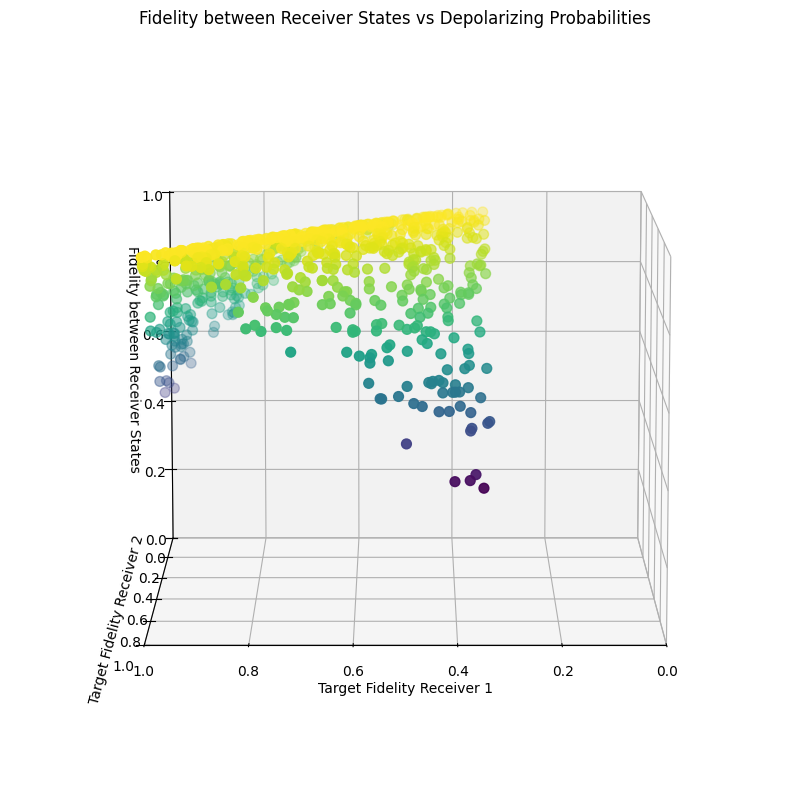

In [7]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[0], points[1], points[2], c=points[2], cmap='viridis', s=50)
ax.set_xlabel('Target Fidelity Receiver 1')
ax.set_ylabel('Target Fidelity Receiver 2')
ax.set_zlabel('Fidelity between Receiver States')
ax.view_init(elev=10, azim=90)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
plt.title('Fidelity between Receiver States vs Depolarizing Probabilities')
plt.show()